<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/Experiment_Policy_REINFORCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [26]:
import requests

raw_url = "https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/autoscaling_env.py"
local_filename = "autoscaling_env.py"

r = requests.get(raw_url)
r.raise_for_status()  # ensures you get an error if download fails

with open(local_filename, "wb") as f:
    f.write(r.content)

print("Downloaded:", local_filename)


Downloaded: autoscaling_env.py


In [27]:
#df_usage_train = df_usage.head(1000)
print(f"df_usage now has {df_usage.shape[0]} rows and {df_usage.shape[1]} columns.")

df_usage now has 10000 rows and 4 columns.


In [28]:
import importlib
import autoscaling_env # Ensure the module is loaded if not already

# Reload the module to pick up the changes
importlib.reload(autoscaling_env)

# Re-import the class and re-initialize the environment
from autoscaling_env import AutoScalingEnv
env = AutoScalingEnv(df_usage_train)

print('Resetting the environment...')
initial_state, initial_info = env.reset()
print(f'Initial State: {initial_state}')
print(f'Initial Info: {initial_info}')

import random
action = random.randint(0, env.action_space.n - 1)
print(f'Taking random action: {action}')

next_state, reward, terminated, truncated, info = env.step(action)

print(f'\nAfter one step:')
print(f'Next State: {next_state}')
print(f'Reward: {reward}')
print(f'Terminated: {terminated}')
print(f'Truncated: {truncated}')
print(f'Info: {info}')

Resetting the environment...
Initial State: [6.6225836e-03 4.9124165e-03 1.0000000e+01]
Initial Info: {'initial_capacity': 10}
Taking random action: 2

After one step:
Next State: [3.2542923e-03 2.7331815e-03 1.1000000e+01]
Reward: -54.50210704835946
Terminated: False
Truncated: False
Info: {'current_capacity': 11, 'utilization': np.float64(5.734555186214497), 'estimated_total_cpu_load': np.float64(63.080107048359466), 'reward_components': {'cost_penalty': -0.022, 'sla_penalty': np.float64(-49.345551862144966), 'util_deviation_penalty': np.float64(-5.134555186214497)}}


### 1. Define the Policy Network
We'll create a simple neural network using TensorFlow/Keras to serve as our policy. This network will map states to action probabilities.

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Get observation and action space dimensions from the environment
observation_space_dim = env.observation_space.shape[0]
action_space_dim = env.action_space.n

# Define the Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1) # Softmax for probabilities over the last dimension
        )

    def forward(self, x):
        return self.network(x)

policy_model = PolicyNetwork(observation_space_dim, action_space_dim).to(device)
print(policy_model)


Using device: cuda
PolicyNetwork(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
    (5): Softmax(dim=-1)
  )
)


### 2. Implement the REINFORCE Algorithm
Now, let's define the REINFORCE algorithm. This involves:
- Collecting trajectories (sequences of states, actions, and rewards) from the environment.
- Calculating the discounted return for each step in the trajectory.
- Updating the policy network using gradient ascent, aiming to increase the probability of actions that led to higher returns.

In [30]:
optimizer = optim.Adam(policy_model.parameters(), lr=0.001)

def discount_rewards(rewards, gamma=0.99):
    discounted_r = np.zeros_like(rewards, dtype=np.float32)
    running_add = 0
    for t in reversed(range(0, len(rewards))):
        running_add = running_add * gamma + rewards[t]
        discounted_r[t] = running_add
    return discounted_r

def train_step(states, actions, returns):
    optimizer.zero_grad()

    # Convert inputs to PyTorch tensors and move to device
    states = torch.tensor(states, dtype=torch.float32).to(device)
    actions = torch.tensor(actions, dtype=torch.int64).to(device) # Use int64 for actions
    returns = torch.tensor(returns, dtype=torch.float32).to(device)

    # Get action probabilities from the policy model
    action_probabilities = policy_model(states)

    # Use Categorical distribution to get log probabilities for the taken actions
    m = torch.distributions.Categorical(action_probabilities)
    log_probs = m.log_prob(actions)

    # Compute the loss (negative log probability weighted by return)
    loss = -torch.sum(log_probs * returns)

    # Perform backpropagation
    loss.backward()
    optimizer.step()

    return loss.item()


### 3. Training Loop
We will now run a number of episodes to train the REINFORCE agent. We'll collect data for each episode and use it to update the policy network.

In [31]:
num_episodes = 200
gamma = 0.99 # Discount factor

episode_rewards = []

for episode in range(num_episodes):
    states, actions, rewards = [], [], []
    state, info = env.reset()
    done = False
    episode_reward = 0
    steps_in_episode = 0

    while not done:
        # Convert state to PyTorch tensor, add batch dimension, and move to device
        state_input = torch.tensor(state[np.newaxis, :], dtype=torch.float32).to(device)

        # Predict action probabilities
        action_probs = policy_model(state_input)

        # Sample an action from the distribution
        m = torch.distributions.Categorical(action_probs)
        action = m.sample().item()

        # Take action in the environment
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)

        state = next_state
        episode_reward += reward
        steps_in_episode += 1

    # Normalize episode reward by steps
    normalized_episode_reward = episode_reward / steps_in_episode if steps_in_episode > 0 else 0

    # Convert lists to NumPy arrays first for discount_rewards, then to PyTorch tensors for train_step
    states_np = np.array(states, dtype=np.float32)
    actions_np = np.array(actions, dtype=np.int32)
    rewards_np = np.array(rewards, dtype=np.float32)

    # Calculate discounted returns
    returns = discount_rewards(rewards_np, gamma)

    # Normalize returns (optional, but often helps training stability)
    returns = (returns - np.mean(returns)) / (np.std(returns) + 1e-8)

    # Perform a training step
    loss = train_step(states_np, actions_np, returns)

    episode_rewards.append(normalized_episode_reward)

    if episode % 10 == 0:
        print(f"Episode {episode}: Total Reward = {episode_reward:.2f}, Normalized Reward = {normalized_episode_reward:.2f}, Loss = {loss:.4f}, Avg Normalized Reward (last 10) = {np.mean(episode_rewards[-10:]):.2f}")

print("\nTraining finished!")


Episode 0: Total Reward = -2119.71, Normalized Reward = -2.12, Loss = -210.4147, Avg Normalized Reward (last 10) = -2.12
Episode 10: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -46.0252, Avg Normalized Reward (last 10) = -1.92
Episode 20: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -0.6791, Avg Normalized Reward (last 10) = -1.87
Episode 30: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -0.4243, Avg Normalized Reward (last 10) = -1.86
Episode 40: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -0.5304, Avg Normalized Reward (last 10) = -1.86
Episode 50: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -1.0122, Avg Normalized Reward (last 10) = -1.86
Episode 60: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -1.3074, Avg Normalized Reward (last 10) = -1.88
Episode 70: Total Reward = -1862.92, Normalized Reward = -1.86, Loss = -0.9933, Avg Normalized Reward (last 10) = -1.86
Episode 80: Total Reward = -1862.92, N

### 4. Evaluate the Trained Agent
Let's visualize the training progress and run a final evaluation episode to see how the agent performs.

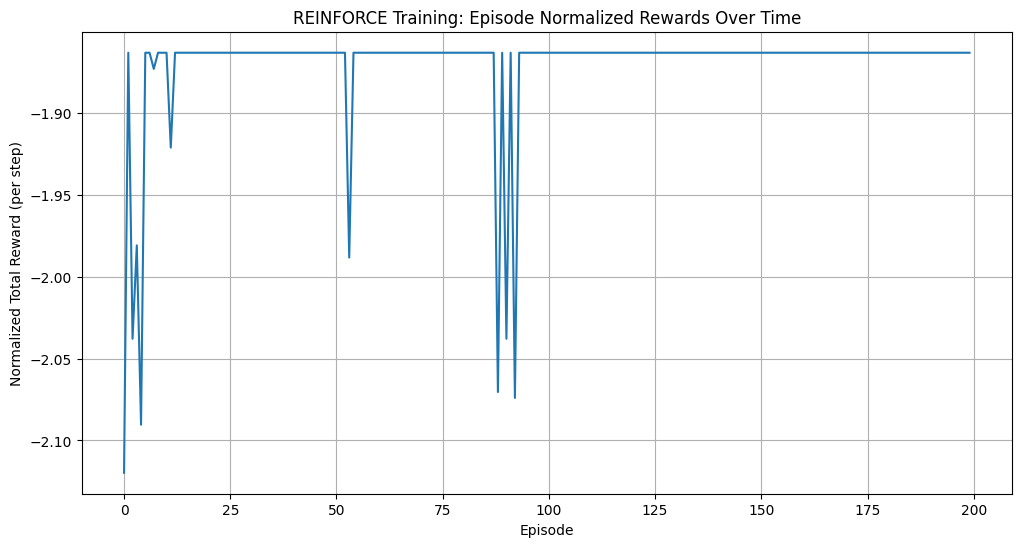


--- Evaluation of Trained Agent ---
Evaluation Episode: Total Reward = -1862.92, Normalized Reward (per step) = -1.86


In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(episode_rewards)
plt.title('REINFORCE Training: Episode Normalized Rewards Over Time')
plt.xlabel('Episode')
plt.ylabel('Normalized Total Reward (per step)')
plt.grid(True)
plt.show()

print("\n--- Evaluation of Trained Agent ---")
state, info = env.reset()
done = False
episode_reward = 0
steps_in_eval_episode = 0

while not done:
    state_input = torch.tensor(state[np.newaxis, :], dtype=torch.float32).to(device)

    # Get action probabilities from the policy model
    with torch.no_grad(): # Disable gradient calculations for inference
        action_probs = policy_model(state_input)

    # Take the most probable action for evaluation
    action = torch.argmax(action_probs).item()

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    state = next_state
    episode_reward += reward
    steps_in_eval_episode += 1

normalized_eval_reward = episode_reward / steps_in_eval_episode if steps_in_eval_episode > 0 else 0
print(f"Evaluation Episode: Total Reward = {episode_reward:.2f}, Normalized Reward (per step) = {normalized_eval_reward:.2f}")


## AGENT Evaluation

In [33]:
import pandas as pd

# Reload the original full df_usage.csv
df_usage_full = pd.read_csv('/content/drive/MyDrive/df_usage.csv')

print(f"df_usage_full now has {df_usage_full.shape[0]} rows and {df_usage_full.shape[1]} columns.")

df_usage_full now has 10000 rows and 4 columns.


### Re-initialize the environment with the full dataset

In [34]:
import importlib
import autoscaling_env

# Reload the module to pick up the changes
importlib.reload(autoscaling_env)

# Re-import the class and re-initialize the environment with the full dataset
from autoscaling_env import AutoScalingEnv
env_full = AutoScalingEnv(df_usage_full)

print('Resetting the environment for full evaluation...')
initial_state_full, initial_info_full = env_full.reset()
print(f'Initial State (Full Env): {initial_state_full}')
print(f'Initial Info (Full Env): {initial_info_full}')

Resetting the environment for full evaluation...
Initial State (Full Env): [6.6225836e-03 4.9124165e-03 1.0000000e+01]
Initial Info (Full Env): {'initial_capacity': 10}


### Run Evaluation on the Full Environment

In [35]:
print("\n--- Evaluation of Trained Agent on Full Data ---")
state_eval, info_eval = env_full.reset()
done_eval = False
episode_reward_eval = 0
steps_in_full_eval_episode = 0

while not done_eval:
    state_input_eval = torch.tensor(state_eval[np.newaxis, :], dtype=torch.float32).to(device)

    # Get action probabilities from the policy model
    with torch.no_grad(): # Disable gradient calculations for inference
        action_probs_eval = policy_model(state_input_eval)

    # Take the most probable action for evaluation
    action_eval = torch.argmax(action_probs_eval).item()

    next_state_eval, reward_eval, terminated_eval, truncated_eval, info_eval = env_full.step(action_eval)
    done_eval = terminated_eval or truncated_eval

    state_eval = next_state_eval
    episode_reward_eval += reward_eval
    steps_in_full_eval_episode += 1

normalized_full_eval_reward = episode_reward_eval / steps_in_full_eval_episode if steps_in_full_eval_episode > 0 else 0
print(f"Evaluation Episode (Full Data): Total Reward = {episode_reward_eval:.2f}, Normalized Reward (per step) = {normalized_full_eval_reward:.2f}")



--- Evaluation of Trained Agent on Full Data ---
Evaluation Episode (Full Data): Total Reward = -13819.49, Normalized Reward (per step) = -1.38
